In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import colorsys
from matplotlib.ticker import PercentFormatter, MultipleLocator


# ============================================================
# Generate vivid distinct colors
# ============================================================
def generate_vivid_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.9
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors


# ============================================================
# Plot multiple result folders
# ============================================================
def plot_multiple_result_dirs(
    dir_list,
    chunk_sizes,
    max_event=650,
    title=None,
    legend_names=None,
    shift_list=None
):

    dir_list = [Path(d) for d in dir_list]

    # ---- chunk size handling ----
    if isinstance(chunk_sizes, int):
        chunk_sizes = [chunk_sizes] * len(dir_list)

    if len(chunk_sizes) != len(dir_list):
        raise ValueError("chunk_sizes must match number of directories")

    # ---- legend names ----
    if legend_names is not None:
        if len(legend_names) != len(dir_list):
            raise ValueError("legend_names must match number of directories")

    # ---- shift ----
    if shift_list is None:
        shift_list = [0] * len(dir_list)

    if len(shift_list) != len(dir_list):
        raise ValueError("shift_list must match number of directories")

    colors = generate_vivid_colors(len(dir_list))

    plt.figure(figsize=(10, 6))

    # ========================================================
    # Loop folders
    # ========================================================
    for dir_idx, result_dir in enumerate(dir_list):

        color = colors[dir_idx]
        chunk_size = chunk_sizes[dir_idx]
        shift = shift_list[dir_idx]

        legend_label = (
            legend_names[dir_idx]
            if legend_names else result_dir.name
        )

        first_plot = True

        for json_file in result_dir.glob("*.json"):

            try:
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])

                events = n * chunk_size + shift

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                if len(events) == 0:
                    continue

                plt.plot(
                    events,
                    avg_eer,
                    linestyle="-",
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=legend_label if first_plot else None
                )

                first_plot = False

            except Exception as e:
                print(f"[ERROR] {json_file}: {e}")

    # ========================================================
    # Axis
    # ========================================================
    ax = plt.gca()
    ax.set_ylim(bottom=0)

    
    ax.yaxis.set_major_locator(MultipleLocator(0.005))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

   
    ax.xaxis.set_major_locator(MultipleLocator(100))

    # ========================================================
    # Labels
    # ========================================================
    plt.xlabel("Events (n * chunk_size)", fontsize=13)
    plt.ylabel("Average EER (%)", fontsize=13)

    if title:
        plt.title(title, fontsize=14, weight="bold")
    else:
        plt.title("Multiple Result Comparison", fontsize=14, weight="bold")

    plt.grid(which='major', axis='both', linestyle='--', alpha=0.35)

    plt.legend(
        fontsize=10,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

## Balabit Protocol1

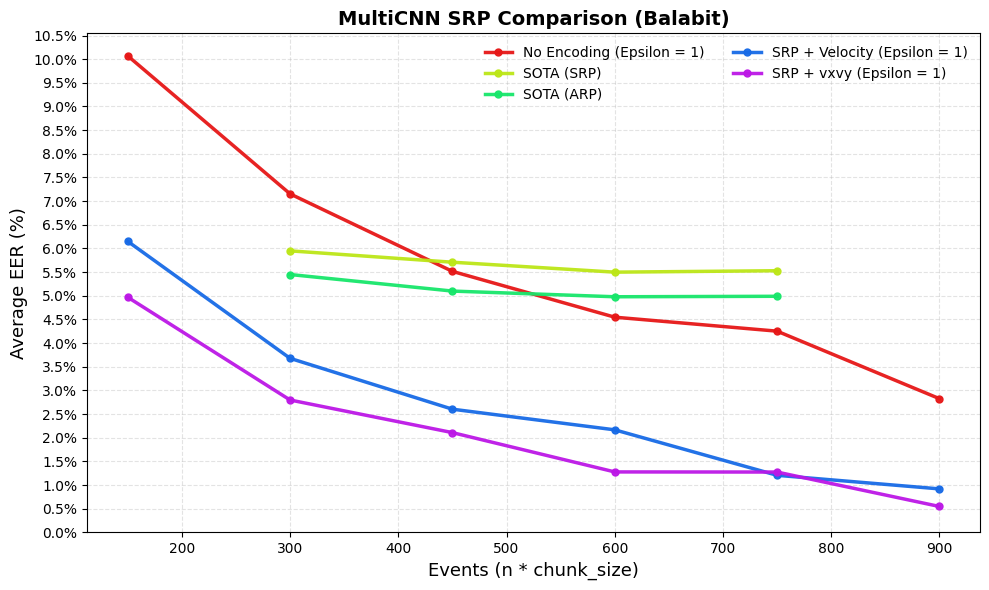

In [10]:
dir_list = [
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon1/Baseline",
    "SOTA_Results/Balabit/SOTA/SRP",
    "SOTA_Results/Balabit/SOTA/ARP",
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon1/VelocityChannel",
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon1/vx_vyChannel"

]

plot_multiple_result_dirs(
    dir_list,
    chunk_sizes=[150, 150, 150, 150, 150],
    max_event=1000,
    title="MultiCNN SRP Comparison (Balabit)",
    legend_names=['No Encoding (Epsilon = 1)', 'SOTA (SRP)', 'SOTA (ARP)' ,'SRP + Velocity (Epsilon = 1)','SRP + vxvy (Epsilon = 1)'],
    shift_list=[0, 150, 150 ,0, 0]  
)

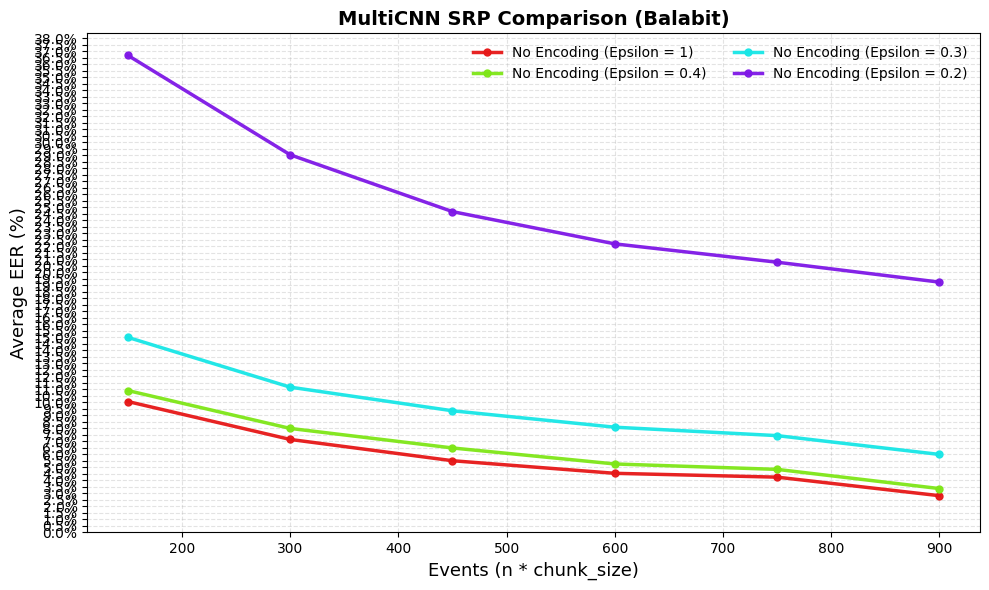

In [11]:
dir_list = [
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon1/Baseline",
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon0.4/Baseline",
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon0.3/Baseline",
    "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon0.2/Baseline"

]

plot_multiple_result_dirs(
    dir_list,
    chunk_sizes=[150, 150, 150, 150],
    max_event=1000,
    title="MultiCNN SRP Comparison (Balabit)",
    legend_names=['No Encoding (Epsilon = 1)', 'No Encoding (Epsilon = 0.4)', 'No Encoding (Epsilon = 0.3)', 'No Encoding (Epsilon = 0.2)'],
    shift_list=[0, 0, 0, 0]  
)

In [12]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon0.4/per-userBaseline/ChunkSize150MultiCNN.json"
json_cdf = "SOTA_Results/Balabit/SRP/MultiCNN/Epsilon1/per-userBaseline/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="epsilon 0.4",
    label_b="epsilon 1",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (epsilon 0.4),Mean EER (epsilon 1),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,epsilon 0.4 vs epsilon 1,1,10,10.91,10.07,0.84,0.003906,True
1,epsilon 0.4 vs epsilon 1,2,10,8.00,7.15,0.85,0.193359,False
2,epsilon 0.4 vs epsilon 1,3,10,6.50,5.52,0.98,0.048828,True
3,epsilon 0.4 vs epsilon 1,4,10,5.27,4.55,0.72,0.083984,False
4,epsilon 0.4 vs epsilon 1,5,10,4.85,4.25,0.60,0.164062,False


In [13]:
from statistics_things.compare_sota import compare_sota_vs_ours, pretty_print

res = compare_sota_vs_ours(
    json_path="SOTA_Results/Balabit/SRP/MultiCNN/Epsilon1/per-userBaseline/ChunkSize150MultiCNN.json",
    sota_csv_path="Results/SOTA/Balabit.csv"
)

pretty_print(res)


==== DEBUG ====
OURS count: 10
SOTA count: 10
OURS users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
SOTA users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']

Paired users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
Paired count: 10

SOTA vs Ours (600-event)
Users: 10
Ours : 4.55%
SOTA : 4.98%

p-value: 0.312500
Significant: False


## Balabit Protocol2

## ChaoShen


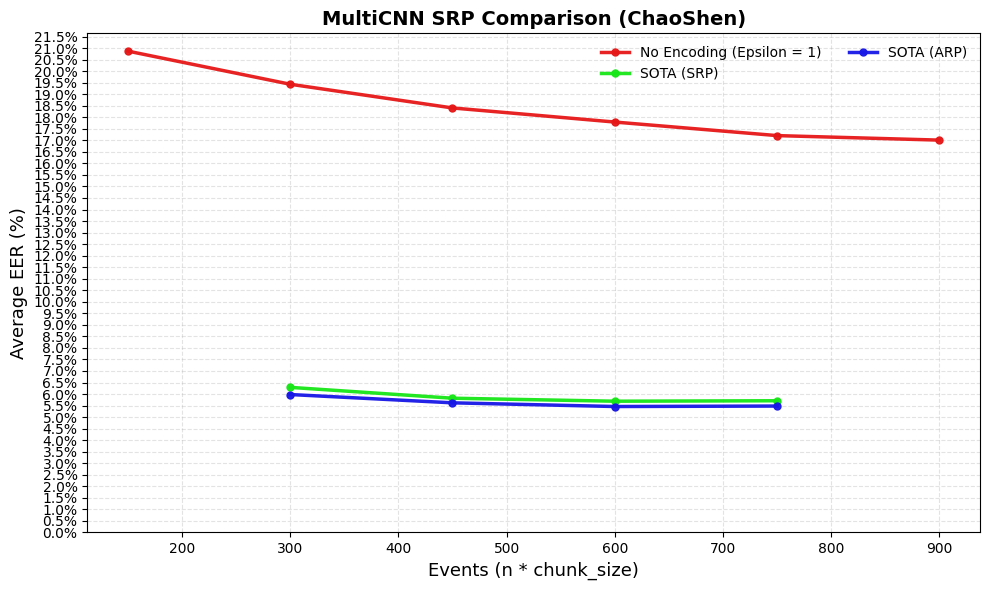

In [14]:
dir_list = [
    "SOTA_Results/ChaoShen/SRP/MultiCNN/Epsilon1/Baseline",
    "SOTA_Results/ChaoShen/SOTA/SRP",
    "SOTA_Results/ChaoShen/SOTA/ARP"

]

plot_multiple_result_dirs(
    dir_list,
    chunk_sizes=[150, 150, 150],
    max_event=1000,
    title="MultiCNN SRP Comparison (ChaoShen)",
    legend_names=['No Encoding (Epsilon = 1)', 'SOTA (SRP)' , 'SOTA (ARP)'],
    shift_list=[0, 150, 150]  
)

## DFL

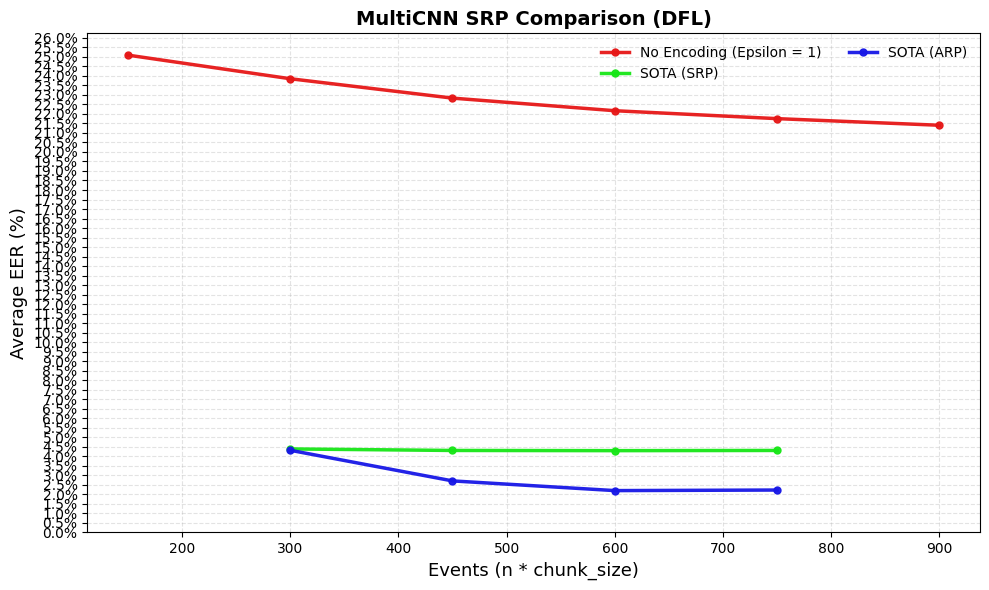

In [17]:
dir_list = [
    "SOTA_Results/DFL/SRP/MultiCNN/Epsilon1/Baseline",
    "SOTA_Results/DFL/SOTA/SRP",
    "SOTA_Results/DFL/SOTA/ARP"

]

plot_multiple_result_dirs(
    dir_list,
    chunk_sizes=[150, 150, 150],
    max_event=1000,
    title="MultiCNN SRP Comparison (DFL)",
    legend_names=['No Encoding (Epsilon = 1)', 'SOTA (SRP)' , 'SOTA (ARP)'],
    shift_list=[0, 150, 150]  
)